<a href="https://colab.research.google.com/github/nouur-mohaamed/CreditCardDefault_ML_Project/blob/main/Credit_card_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)


# Visualize the fetched data ( features and targets )

In [ ]:
default_of_credit_card_clients.data

{'ids':           ID
 0          1
 1          2
 2          3
 3          4
 4          5
 ...      ...
 29995  29996
 29996  29997
 29997  29998
 29998  29999
 29999  30000
 
 [30000 rows x 1 columns],
 'features':            X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...     X14    X15    X16  \
 0       20000   2   2   1  24   2   2  -1  -1   -2  ...     689      0      0   
 1      120000   2   2   2  26  -1   2   0   0    0  ...    2682   3272   3455   
 2       90000   2   2   2  34   0   0   0   0    0  ...   13559  14331  14948   
 3       50000   2   2   1  37   0   0   0   0    0  ...   49291  28314  28959   
 4       50000   1   2   1  57  -1   0  -1   0    0  ...   35835  20940  19146   
 ...       ...  ..  ..  ..  ..  ..  ..  ..  ..  ...  ...     ...    ...    ...   
 29995  220000   1   3   1  39   0   0   0   0    0  ...  208365  88004  31237   
 29996  150000   1   3   2  43  -1  -1  -1  -1    0  ...    3502   8979   5190   
 29997   30000   1   2   2  37   4   3   2  -1

In [ ]:
features=default_of_credit_card_clients.data.features
features

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [ ]:
targets=default_of_credit_card_clients.data.targets
targets

,Y
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


In [ ]:
full_credit_card_data_table=pd.concat([features,targets],axis=1)
full_credit_card_data_table

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


# playing with pandas data frame

In [ ]:
print(full_credit_card_data_table[['X1','X15']].head()) # get multiple columns (panda data frame 'subset')

       X1    X15
0   20000      0
1  120000   3272
2   90000  14331
3   50000  28314
4   50000  20940


In [ ]:
print(full_credit_card_data_table[['X3']].head()) # get one column (pandas series)

   X3
0   2
1   2
2   2
3   2
4   2


In [ ]:
full_credit_card_data_table.loc[[0,5,7]] # get rows 0, 5, 7

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
5,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0


In [ ]:
full_credit_card_data_table.loc[[4]] # get row 4 as a data frame

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
full_credit_card_data_table.loc[4] # get row 4 as a series (where column names are indices)

,4
X1,50000
X2,1
X3,2
X4,1
X5,57
X6,-1
X7,0
X8,-1
X9,0
X10,0


In [ ]:
full_credit_card_data_table.iloc[2:6,3] # get column of index 3 (column X4) from row 0f index 2 till row of index 5 (excluding row of index 6)

,X4
2,2
3,1
4,1
5,2


# understanding the data set

In [ ]:
full_credit_card_data_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [ ]:
full_credit_card_data_table.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


know the data types of features

In [ ]:
full_credit_card_data_table.dtypes

,0
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64
X7,int64
X8,int64
X9,int64
X10,int64


testing null values

In [ ]:
full_credit_card_data_table.isnull().sum() # no null values

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0


testing the balance of data

In [ ]:
full_credit_card_data_table['Y'].value_counts() # get the count of classes in a column

,count
Y,
0,23364
1,6636


In [ ]:
not_default=full_credit_card_data_table['Y'].value_counts()[0]
default=full_credit_card_data_table['Y'].value_counts()[1]
print(f"the percentage of the not default: {round((not_default/(default+not_default))*100)}%")
print(f"the percentage of the default: {round((default/(default+not_default))*100)}%")

the percentage of the not default: 78%
the percentage of the default: 22%


<Axes: xlabel='Y'>

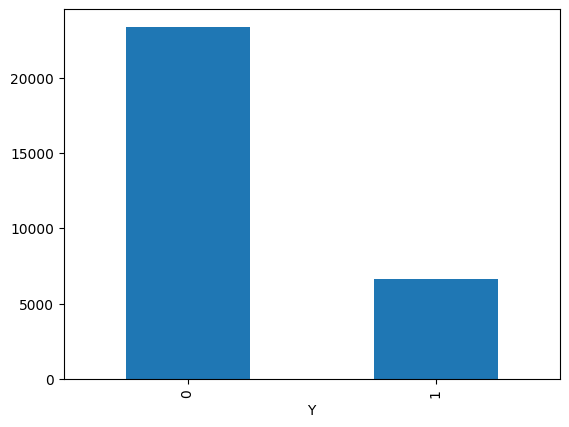

In [ ]:
full_credit_card_data_table['Y'].value_counts().plot(kind='bar') # data is imbalanced

# DAY 1 REPORT
*   number of samples: 30,000
*   number of features: 23
*   Target : default? [ 1--> yes , 0--> no ]
*   missing values : no
*   Numerical features: Amount of the given credit,Age,Amount of bill statement,Amount of previous payment
*   Categorical features: Gender,Education,Marital status,History of past payment
* Class 0 percentage: 78%
* Class 1 percentage: 22%
### features meaning:
* Amount of the given credit [X1]: the credit limit given to that person (can't exceed)
* Amount of bill statement [X12-X17]: how much does he owe the bank at this month report
* Amount of previous payment[X18-X23]: how much of what he was owed did he pay at this month report
* History of past payment[X6 - X11]: what is his payment status at this month report ( was he delayed or not and by how many months was he delayed)






# preprocessing

In [ ]:
full_credit_card_data_table_encoded=full_credit_card_data_table.copy()

In [ ]:
full_credit_card_data_table_encoded['X2']=full_credit_card_data_table_encoded['X2'].replace([1,2],[0,1]) # male-> 0 / female-> 1
full_credit_card_data_table_encoded

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,1,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,1,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,1,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,1,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,0,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,0,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,0,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,0,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,0,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [ ]:
marital_status_data = []
for marital_status in full_credit_card_data_table_encoded['X4']:
  if marital_status==1:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':0
    })
  elif marital_status==2:
    marital_status_data.append({
        'marital_status_msb':0,
        'marital_status_lsb':1
    })
  else:
    marital_status_data.append({
        'marital_status_msb':1,
        'marital_status_lsb':0
    })
marital_status_df = pd.DataFrame(marital_status_data)
marital_status_df

,marital_status_msb,marital_status_lsb
0,0,0
1,0,1
2,0,1
3,0,0
4,0,0
...,...,...
29995,0,0
29996,0,1
29997,0,1
29998,0,0


In [ ]:
encoded_table_target=full_credit_card_data_table_encoded['Y']
full_credit_card_data_table_encoded.drop(columns=['X4','Y'],inplace=True)
full_credit_card_data_table_encoded=pd.concat([full_credit_card_data_table_encoded,marital_status_df,encoded_table_target],axis=1)
full_credit_card_data_table_encoded

,X1,X2,X3,X5,X6,X7,X8,X9,X10,X11,...,X17,X18,X19,X20,X21,X22,X23,marital_status_msb,marital_status_lsb,Y
0,20000,1,2,24,2,2,-1,-1,-2,-2,...,0,0,689,0,0,0,0,0,0,1
1,120000,1,2,26,-1,2,0,0,0,2,...,3261,0,1000,1000,1000,0,2000,0,1,1
2,90000,1,2,34,0,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,1,0
3,50000,1,2,37,0,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,0,0
4,50000,0,2,57,-1,0,-1,0,0,0,...,19131,2000,36681,10000,9000,689,679,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,0,3,39,0,0,0,0,0,0,...,15980,8500,20000,5003,3047,5000,1000,0,0,0
29996,150000,0,3,43,-1,-1,-1,-1,0,0,...,0,1837,3526,8998,129,0,0,0,1,0
29997,30000,0,2,37,4,3,2,-1,0,0,...,19357,0,0,22000,4200,2000,3100,0,1,1
29998,80000,0,3,41,1,-1,0,0,0,-1,...,48944,85900,3409,1178,1926,52964,1804,0,0,1
